In [1]:
from backtest_engine import *
import numpy as np
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]

df = request(
    ticker="SPY",
    config=config,
)

Loading data from local cache: cache_SPY_20170101_20260620.parquet


In [2]:
# instantiate a portfolio backtest - behaviour is swapped via strategy=/execution=/cost_model= kwargs instead of subclassing
p = Portfolio(df)

print(p)
print(p.sharpe)

Portfolio(AUM: $100,000, Sharpe: 1.15, Period: [2017-01-26 - 2026-06-18])
1.154047650646071


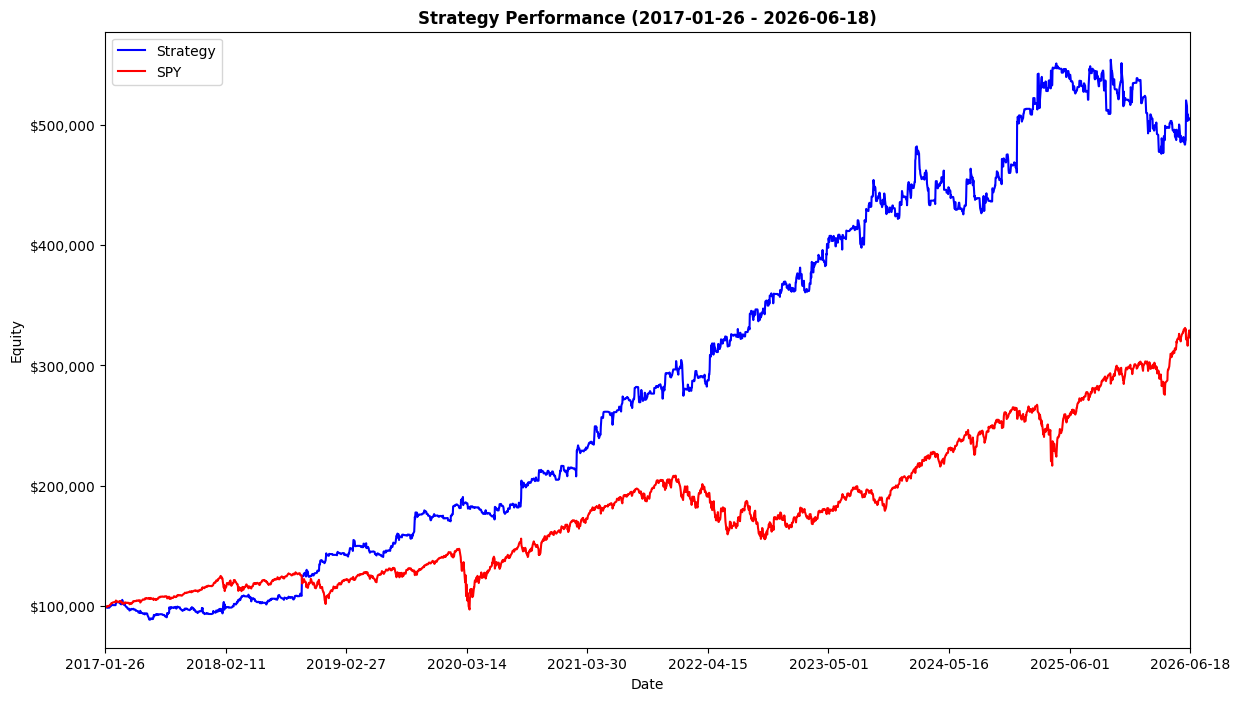

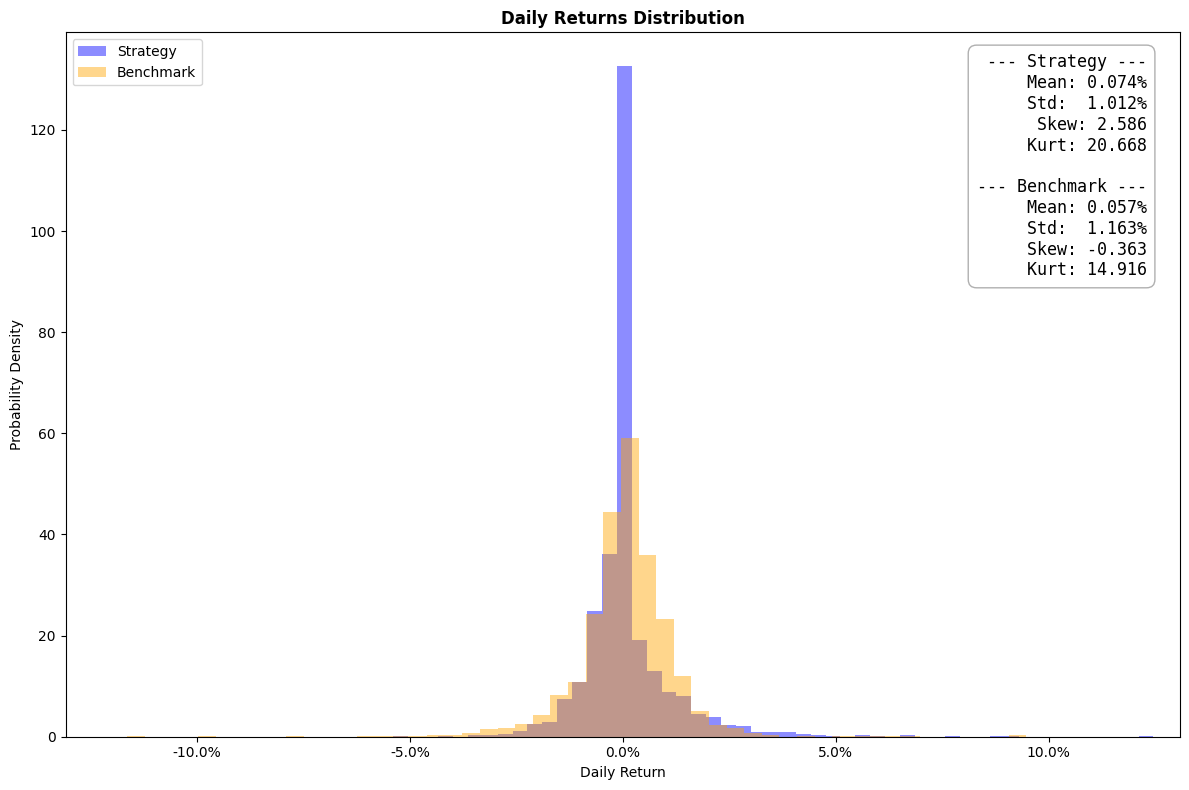

                                Strategy      Benchmark
Total Days                         2,362
Cum. Return                      404.60%        230.32%
Ann. Return                       18.85%         13.60%
Avg. Daily Return                  0.07%          0.06%
Ret. Skew                           2.59          -0.36
Ret. Kurtosis                      20.67          14.92
Max Gain                          12.46%          9.47%
Best Day                      2018-10-10     2020-03-24
Max Loss                          -5.39%        -11.63%
Worst Day                     2018-02-06     2020-03-16
Win Rate                          42.10%              -
Daily Win Rate                    29.68%         55.63%
Average Trades / Day                1.00              -
Average Return / Trade              0.00              -
Alpha                               0.20              -
Beta                               -0.10              -
R-Squared                           0.01              -
Ann. Vo

In [3]:
# backtest result over the entire data range provided
# returns a Tearsheet object when decompose param is false (default)
print(p.report())

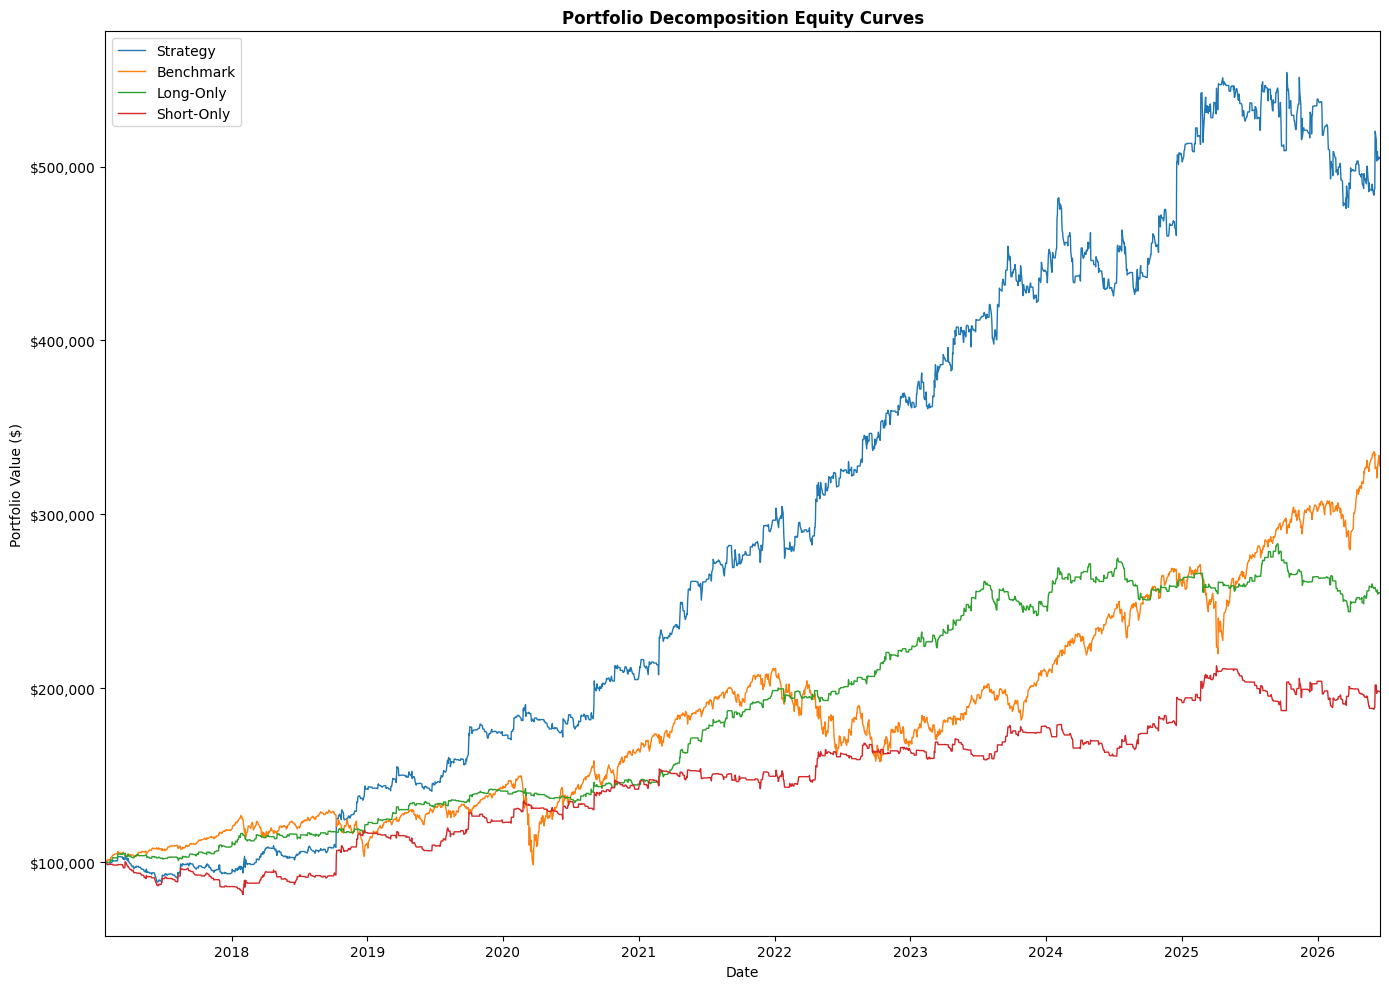

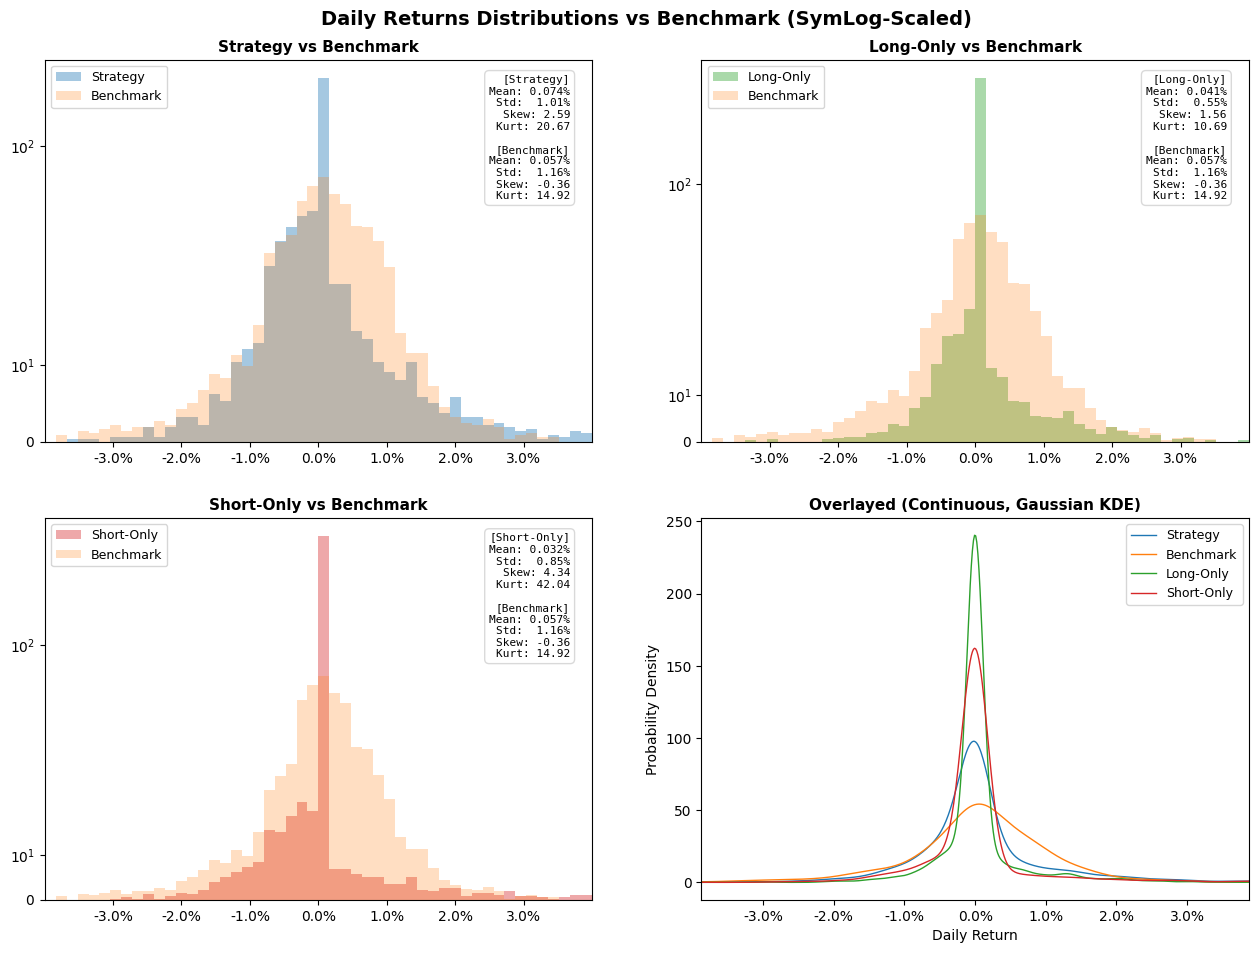

                                Strategy     Strat_Long     Short-Only      Benchmark
-------------------------------------------------------------------------------------
Total Days                         2,362          2,362          2,362              -
Cum. Return                      404.60%        154.89%         97.97%        230.32%
Ann. Return                       18.85%         10.50%          7.56%         13.60%
Avg. Daily Return                  0.07%          0.04%          0.03%          0.06%
Ret. Skew                           2.59           1.56           4.34          -0.36
Ret. Kurtosis                      20.67          10.69          42.04          14.92
Max Gain                          12.46%          4.22%         12.46%          9.47%
Best Day                      2018-10-10     2018-12-26     2018-10-10     2020-03-24
Max Loss                          -5.39%         -3.22%         -4.28%        -11.63%
Worst Day                     2018-02-06     2024-05-0

In [4]:
# backtest decomposed into long and short legs
# returns a PortfolioDecomposer object
print(p.report(decompose=True))

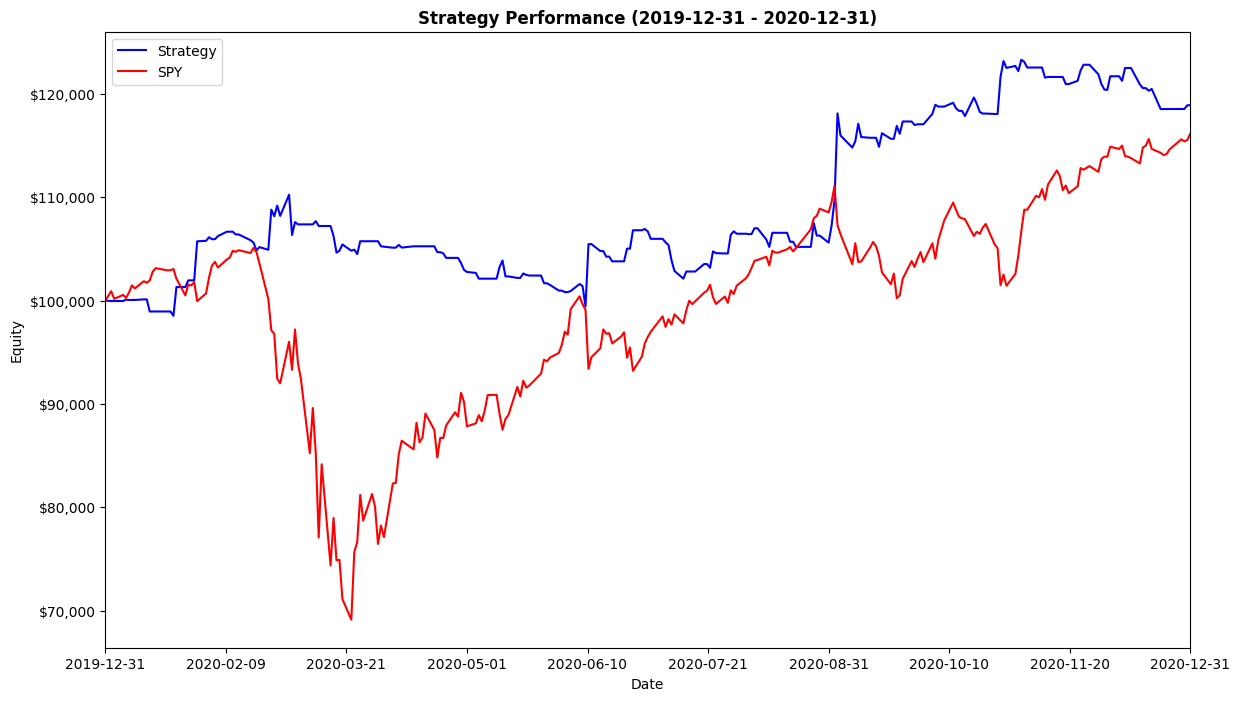

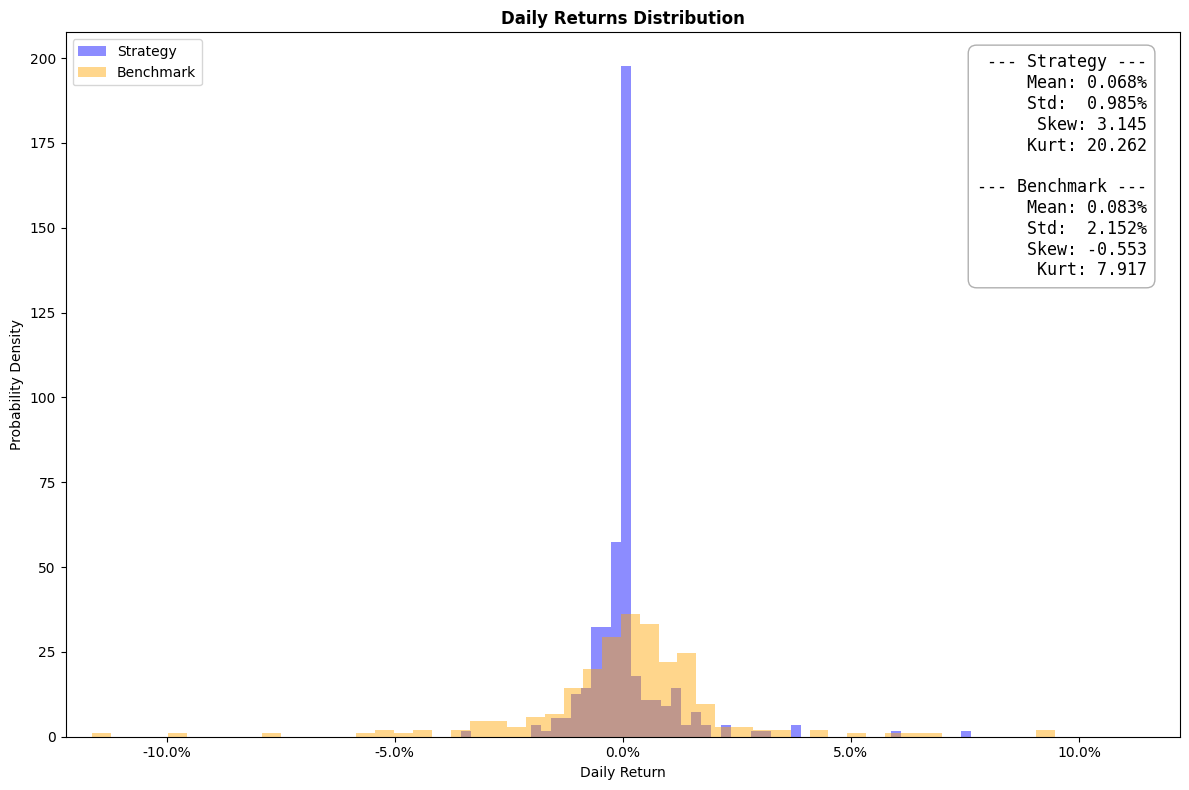

                                Strategy      Benchmark
Total Days                           254
Cum. Return                       17.42%         16.43%
Ann. Return                       17.27%         16.29%
Avg. Daily Return                  0.07%          0.08%
Ret. Skew                           3.15          -0.55
Ret. Kurtosis                      20.26           7.92
Max Gain                           7.63%          9.47%
Best Day                      2020-09-03     2020-03-24
Max Loss                          -3.54%        -11.63%
Worst Day                     2020-03-03     2020-03-16
Win Rate                          39.74%              -
Daily Win Rate                    25.59%         57.87%
Average Trades / Day                0.92              -
Average Return / Trade              0.00              -
Alpha                               0.18              -
Beta                               -0.05              -
R-Squared                           0.01              -
Ann. Vo

In [5]:
# backtest result over the provided date range
print(p.report(start=date(2020, 1, 1), end=date(2021, 1, 1))) 

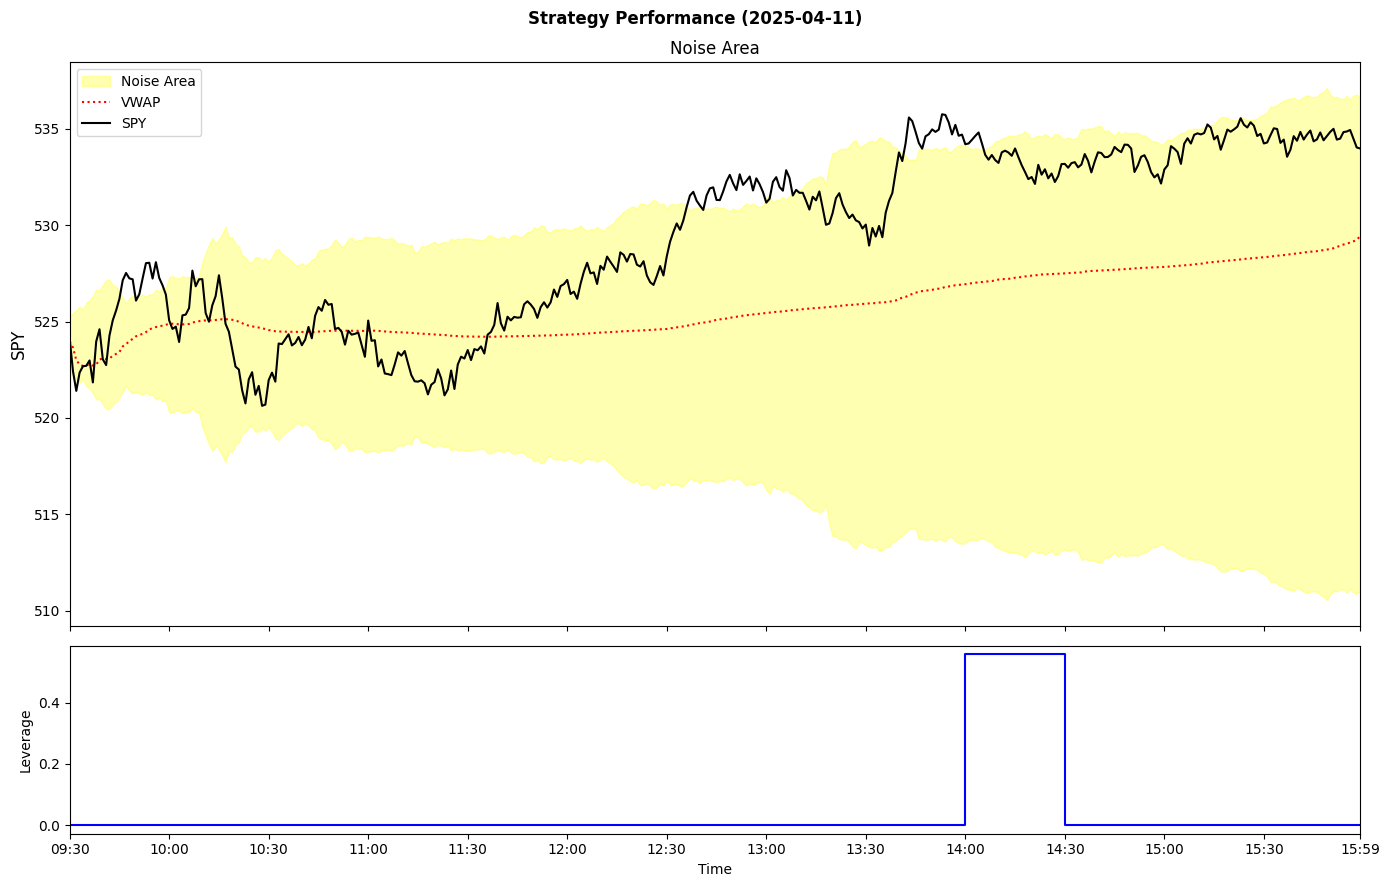

                                Strategy      Benchmark
Cum. Return                       -0.11%          1.77%


In [6]:
# strategy actions over a specific day
# heavily tailored to visualise the SFI paper's strategy and will need to be rewritten for different strategies
print(p.report(day=date(2025, 4, 12)))

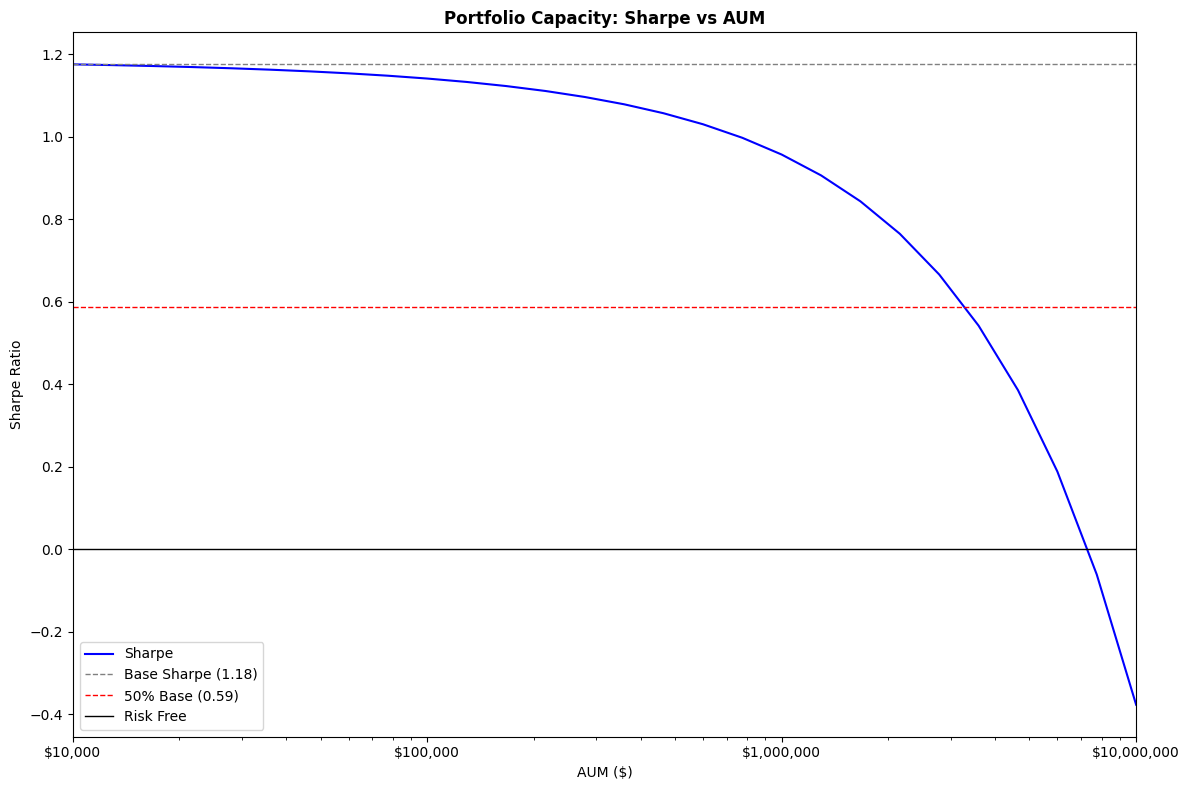

ValueError: too many values to unpack (expected 2)

In [9]:
# classmethod, visualises capacity of a strategy
Portfolio.sharpe_curve(df=df, max_aum=10_000_000, cost_model=DynamicCostModel(), execution=CappedVolumeRolloverExecution())
Portfolio.sharpe_curve(df=df, max_aum=10_000_000, cost_model=DynamicCostModel(), execution=CappedVolumeExecution())

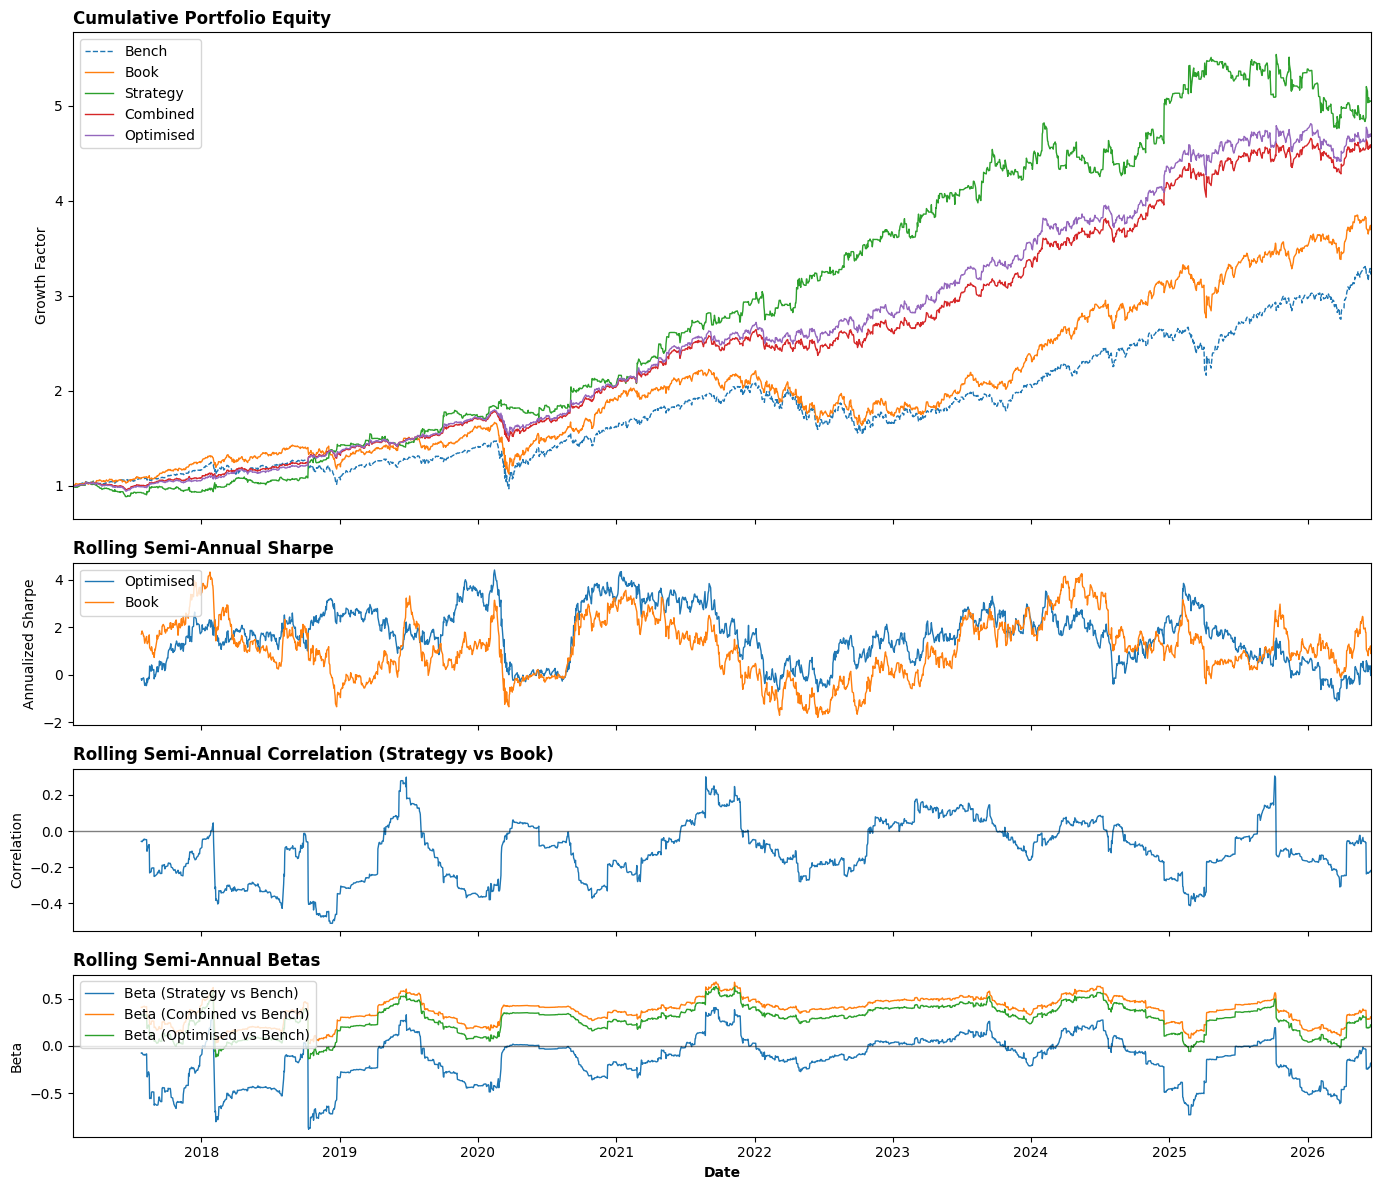

=== Portfolio Integration & Risk Report ===
                                    Book   Strategy   Combined  Optimised    Bench
Expected Return                   15.68%     18.54%     16.87%     17.13%   14.30%
Volatility                        18.28%     16.07%     11.37%     11.33%   18.45%
Sharpe Ratio                        0.86       1.15       1.48       1.51     0.77
Beta                                0.90      -0.10       0.39       0.31     1.00
Skewness                           -0.39       2.59       0.51       0.85    -0.36
Kurtosis                            9.78      20.67       6.05       6.56    14.94
Max Drawdown                     -32.54%    -15.71%    -17.78%    -15.03%  -34.23%
Max DD Days                          558        255        204        150      512
Max DD Recovery Days                 114        195        113        109      103
Correlation to Book                    -      -0.11       0.71       0.56        -
Crash Correlation to Book              -   

In [8]:
ps = Portfolio(df, cost_model=DynamicCostModel(), long_permissions=False)

toy_book, _ = generate_toy_equity( # generate a toy book equity series
    portfolio=p,
    sharpe=1,
    volatility=0.18,
    beta=0.9,
    benchmark=df["close"],
)

sc = StrategyConnector(p, toy_book, df["close"]) # instantiate StrategyConnector tool to analyse strategy integration into current toy book

sc.report()